# TS3 (Cuantización ADC)

Cuantizador uniforme midrise de B bits sobre una senoidal de potencia unitaria. Se analizan:
- Señal cuantizada vs referencia
- Error de cuantización y su distribución
- Autocorrelación del error
- SQNR medido vs teórico

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
fs       = 1000          # Hz, frecuencia de muestreo
N        = 1000          # muestras totales
f0       = fs / N        # Hz, 1 ciclo exacto en la ventana
A        = np.sqrt(2)    # amplitud → P = A²/2 = 1 W
VF       = 2.0           # V, fondo de escala (rango ±VF)
B_values = [4, 8, 16]    # bits de cuantización a comparar

t  = np.arange(N) / fs
sR = A * np.sin(2 * np.pi * f0 * t)

## Cuantizador

In [14]:
def quantize(s, B, VF):
    q      = 2 * VF / 2**B
    s_clip = np.clip(s, -VF, VF)
    s_q    = q * (np.floor(s_clip / q) + 0.5)
    s_q    = np.clip(s_q, -VF, VF)
    return s_q, q

## sR vs sQ

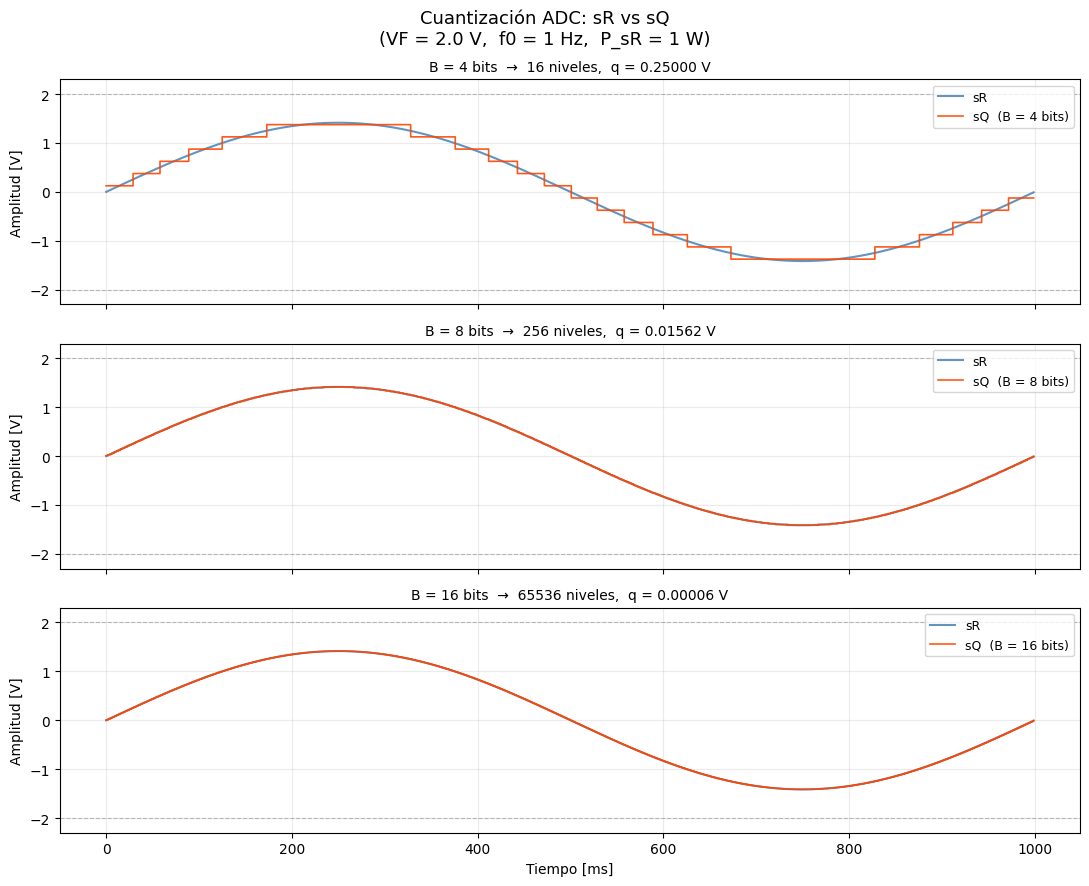

In [15]:
fig1, axes1 = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig1.suptitle(
    f'Cuantización ADC: sR vs sQ\n'
    f'(VF = {VF} V,  f0 = {f0:.0f} Hz,  P_sR = 1 W)',
    fontsize=13
)

t_ms = t * 1e3

for ax, B in zip(axes1, B_values):
    sQ, q = quantize(sR, B, VF)

    ax.plot(t_ms, sR, color='steelblue', lw=1.5, alpha=0.85, label='sR')
    ax.step(t_ms, sQ, color='orangered', lw=1.2, alpha=0.90,
            where='post', label=f'sQ  (B = {B} bits)')
    ax.axhline( VF, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.axhline(-VF, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_ylim(-VF * 1.15, VF * 1.15)
    ax.set_ylabel('Amplitud [V]')
    ax.set_title(f'B = {B} bits  →  {2**B} niveles,  q = {q:.5f} V', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes1[-1].set_xlabel('Tiempo [ms]')
plt.tight_layout()
plt.show()

## Error de cuantización

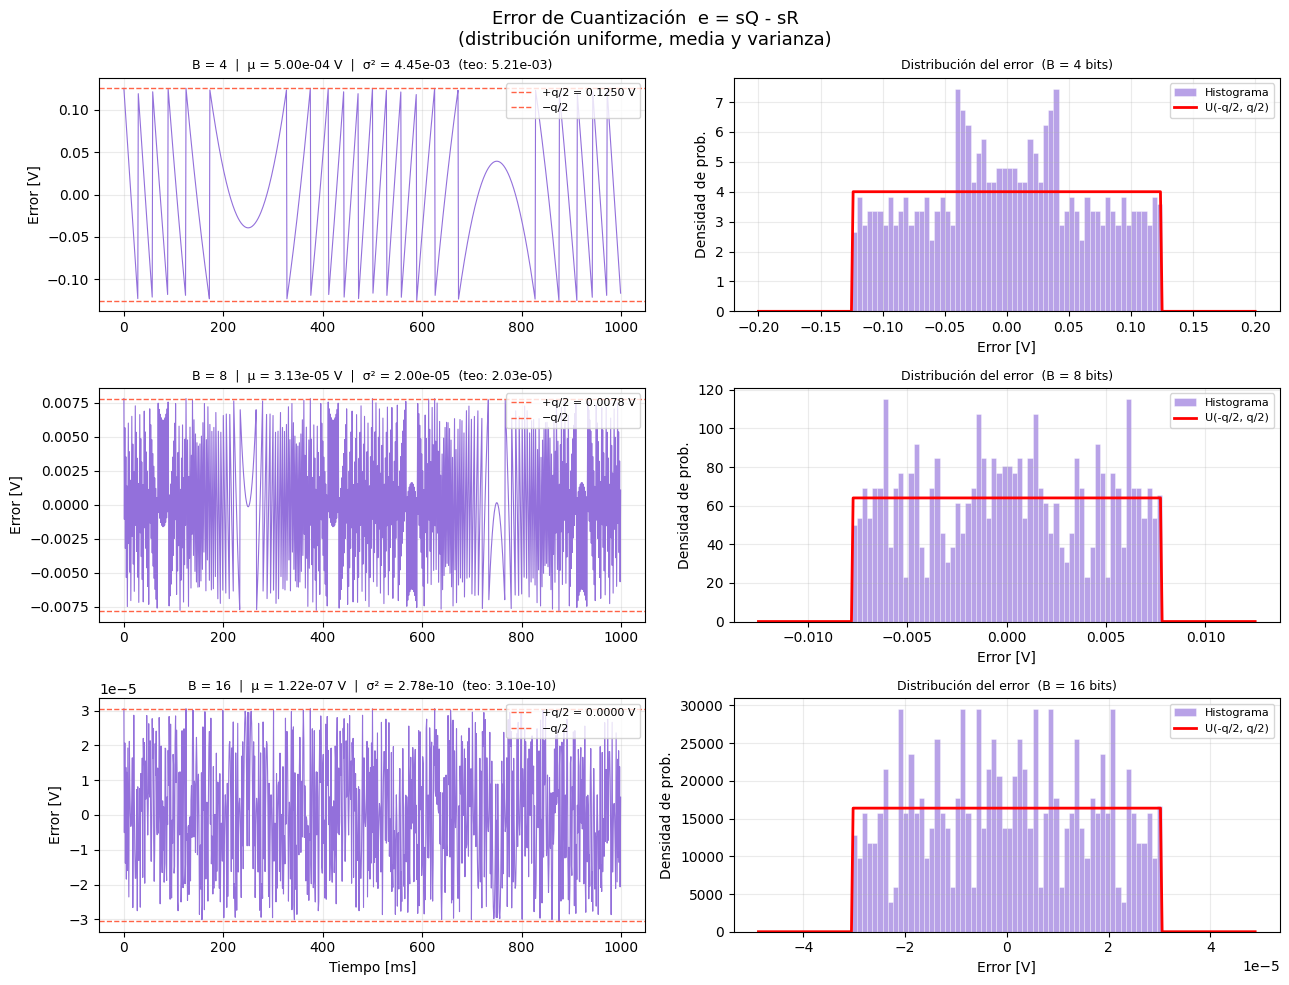

In [16]:
fig2, axes2 = plt.subplots(3, 2, figsize=(13, 10))
fig2.suptitle(
    'Error de Cuantización  e = sQ - sR\n'
    '(distribución uniforme, media y varianza)',
    fontsize=13
)

for row, B in enumerate(B_values):
    sQ, q   = quantize(sR, B, VF)
    e       = sQ - sR
    mean_e  = np.mean(e)
    var_e   = np.var(e)
    var_teo = q**2 / 12

    ax_t = axes2[row, 0]
    ax_t.plot(t_ms, e, color='mediumpurple', lw=0.8)
    ax_t.axhline( q / 2, color='tomato', ls='--', lw=1.0, label=f'+q/2 = {q/2:.4f} V')
    ax_t.axhline(-q / 2, color='tomato', ls='--', lw=1.0, label=f'−q/2')
    ax_t.set_ylabel('Error [V]')
    ax_t.set_title(
        f'B = {B}  |  μ = {mean_e:.2e} V  |  σ² = {var_e:.2e}  (teo: {var_teo:.2e})',
        fontsize=9
    )
    ax_t.legend(fontsize=8, loc='upper right')
    ax_t.grid(True, alpha=0.25)

    ax_h = axes2[row, 1]
    ax_h.hist(e, bins=60, density=True, color='mediumpurple', alpha=0.65,
              edgecolor='white', lw=0.4, label='Histograma')
    x_u = np.linspace(-q * 0.8, q * 0.8, 300)
    y_u = np.where(np.abs(x_u) < q / 2, 1.0 / q, 0.0)
    ax_h.plot(x_u, y_u, 'r-', lw=2, label='U(-q/2, q/2)')
    ax_h.set_xlabel('Error [V]')
    ax_h.set_ylabel('Densidad de prob.')
    ax_h.set_title(f'Distribución del error  (B = {B} bits)', fontsize=9)
    ax_h.legend(fontsize=8)
    ax_h.grid(True, alpha=0.25)

axes2[-1, 0].set_xlabel('Tiempo [ms]')
plt.tight_layout()
plt.show()

## Autocorrelación del error

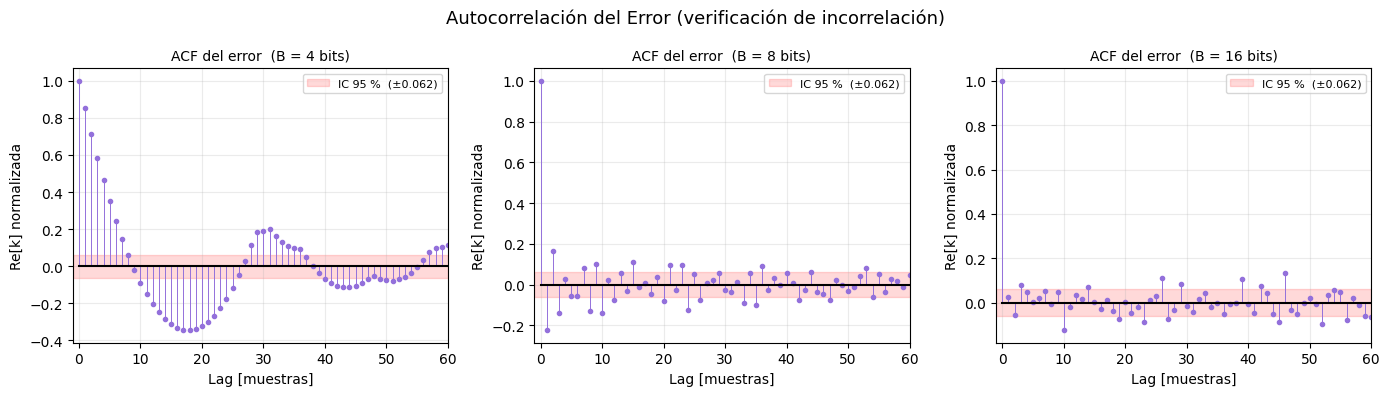

In [17]:
MAX_LAG = 60

fig3, axes3 = plt.subplots(1, 3, figsize=(14, 4))
fig3.suptitle(
    'Autocorrelación del Error (verificación de incorrelación)',
    fontsize=13
)

for ax, B in zip(axes3, B_values):
    sQ, q = quantize(sR, B, VF)
    e     = sQ - sR
    e_c   = e - np.mean(e)

    corr  = np.correlate(e_c, e_c, mode='full')
    corr /= corr[N - 1]
    mid   = N - 1
    lags  = np.arange(MAX_LAG + 1)
    acf   = corr[mid : mid + MAX_LAG + 1]

    ml, sl, bl = ax.stem(lags, acf, linefmt='mediumpurple', markerfmt='o', basefmt='k-')
    ml.set_markersize(3)
    sl.set_linewidth(0.7)

    ci = 1.96 / np.sqrt(N)
    ax.axhspan(-ci, ci, alpha=0.15, color='red', label=f'IC 95 %  (±{ci:.3f})')
    ax.set_title(f'ACF del error  (B = {B} bits)', fontsize=10)
    ax.set_xlabel('Lag [muestras]')
    ax.set_ylabel('Re[k] normalizada')
    ax.set_xlim(-1, MAX_LAG)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## SQNR

In [18]:
print(f"{'B':>4}  {'q [V]':>10}  {'μ [V]':>10}  {'σ² medida':>12}  {'σ² teo':>12}  {'SQNR [dB]':>10}  {'SQNR teo':>10}")
for B in B_values:
    sQ, q  = quantize(sR, B, VF)
    e      = sQ - sR
    var_e  = np.var(e)
    sqnr   = 10 * np.log10(np.mean(sR**2) / var_e)
    sqnr_t = 6.02 * B + 1.76
    print(f"{B:>4}  {q:>10.5f}  {np.mean(e):>10.2e}  {var_e:>12.2e}  {q**2/12:>12.2e}  {sqnr:>10.2f}  {sqnr_t:>10.2f}")

   B       q [V]       μ [V]     σ² medida        σ² teo   SQNR [dB]    SQNR teo
   4     0.25000    5.00e-04      4.45e-03      5.21e-03       23.52       25.84
   8     0.01562    3.13e-05      2.00e-05      2.03e-05       46.99       49.92
  16     0.00006    1.22e-07      2.78e-10      3.10e-10       95.56       98.08
